In [2]:
import cv2
import numpy as np 
import torch
import matplotlib.pyplot as plt

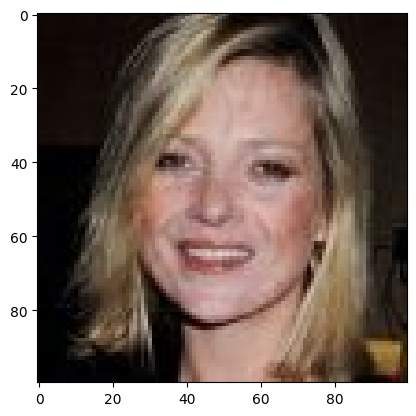

In [8]:
#im = cv2.imread("data/cloaked/cloak_pubfig_small_flat_Facenet_cosine_pgd_cloak_triplet_10_triplet_10_32_multi_finetune__lpips_50.0_mp_32_p_32/AngelinaJolie_21.jpg")
im = cv2.imread("data/cloaked/test_pgd_dssim_5.0/KateMoss_56.jpg")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)

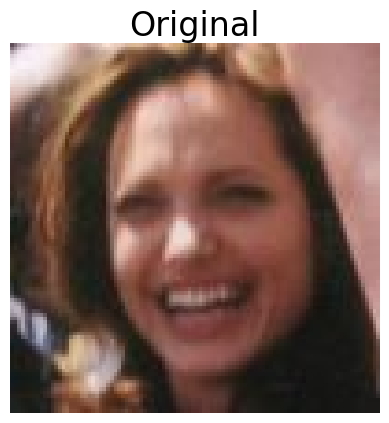

[ WARN:0@1802.473] global loadsave.cpp:268 findDecoder imread_('data/cloaked/cloak_pubfig_small_flat_Facenet_cosine_pgd_cloak_triplet_10_triplet_2_32_multi_finetune__perts_2_32/AngelinaJolie_21.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


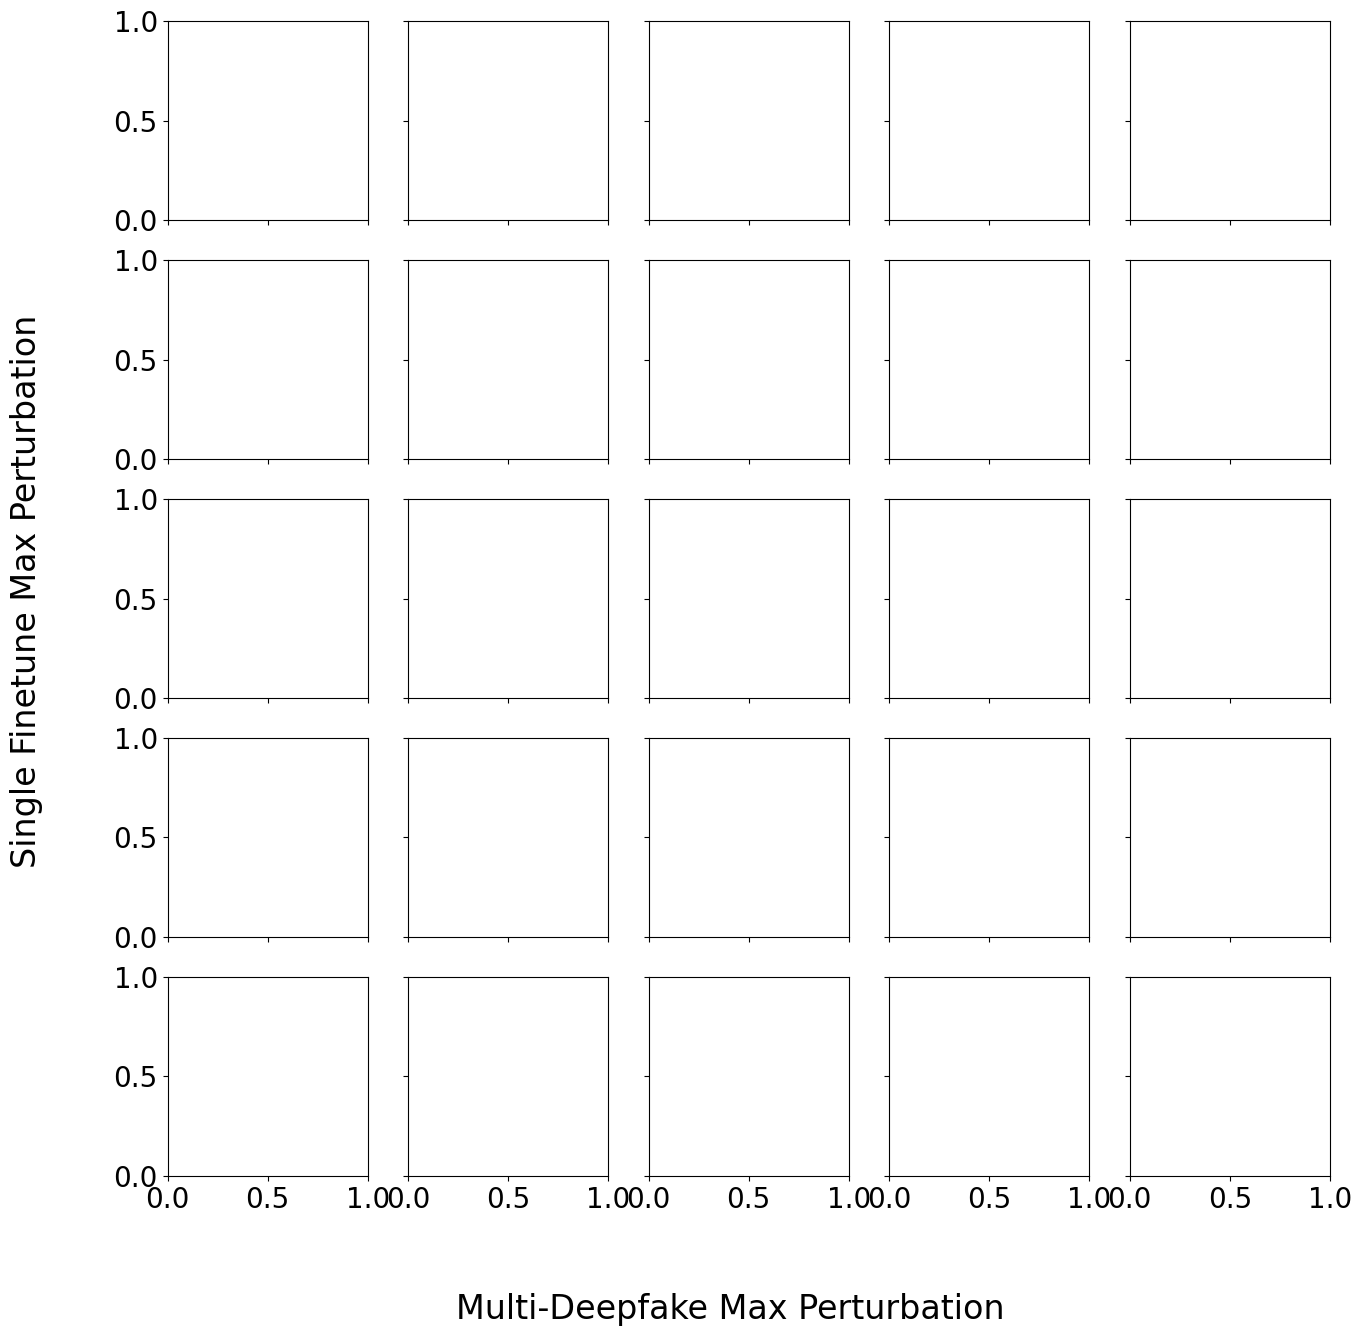

In [ ]:
def parse_type(type):
    data = type.split("_")
    data.pop(2)
    parsed_type=f"dist={data[0]},\noptim={data[1]},\nmulti_loss={data[2]} {data[3]},\nfinetune_loss={data[4]} {data[5]},\n perts={data[6]},\n method={data[7:]}"
    return parsed_type

person = "AngelinaJolie_21.jpg"
dataset = "pubfig_small_flat"
pert_max = ["2", "4", "8", "16", "32"]
multi_max = ["2", "4", "8", "16", "32"]

im = cv2.imread(f"data/{dataset}/{person}")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
plt.axis('off')
plt.title("Original")
plt.show()

plt.rcParams.update({'font.size':20})


fig, ax = plt.subplots(len(pert_max), len(multi_max), sharex='col', sharey='row', figsize=(3*len(pert_max), 3*len(multi_max)))
fig.supylabel("Single Finetune Max Perturbation")
fig.supxlabel("Multi-Deepfake Max Perturbation")
for i, type in enumerate(reversed(pert_max)):
    for j, model in enumerate(multi_max):
        path = f"data/cloaked/cloak_pubfig_small_flat_Facenet_cosine_pgd_cloak_triplet_10_triplet_10_{type}_multi_finetune__perts_{model}_{type}/{person}"
        im = cv2.imread(path)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i,j].imshow(im)
        if i == len(pert_max) - 1:
            ax[i,j].set_xlabel(model)
        if j == 0:
            #ax[i,j].set_ylabel(parse_type(type), rotation=0, labelpad=5, va='center', ha='right')
            ax[i,j].set_ylabel(type)

plt.tight_layout()
plt.show()
